# 00 — Context

## Revision Demystifies Small Language Models

This first notebook does only three things:

1. loads the local `src/pruning_rml` package,
2. creates a reset / observe / revision table,
3. saves one figure to `figures/`.

No model downloads. No GPU. No report generation.

In [53]:
from pathlib import Path
import sys

# Works from repo root or from notebooks/
cwd = Path.cwd().resolve()
repo = cwd.parent if cwd.name == "notebooks" else cwd
src = repo / "src"

sys.path.insert(0, str(src))

print("repo:", repo)
print("src :", src)
print("src exists:", src.exists())

repo: /content/pruning-rml
src : /content/pruning-rml/src
src exists: True


In [54]:
import pandas as pd
import matplotlib.pyplot as plt

from pruning_rml.comparisons import label_mode
from pruning_rml.paths import ensure_dirs

outputs = ensure_dirs(repo)
figures = outputs["figures"]

In [55]:
rows = [
    {
        "section": "Reset",
        "method": "training from scratch",
        "mode": label_mode("training from scratch"),
        "question": "Can capability be rebuilt?"
    },
    {
        "section": "Observe",
        "method": "matched-budget comparison",
        "mode": label_mode("matched-budget comparison"),
        "question": "When does revision outperform reset?"
    },
    {
        "section": "Revision",
        "method": "prune larger pretrained model",
        "mode": label_mode("prune larger pretrained model"),
        "question": "Which capabilities survive compression?"
    },
]

df = pd.DataFrame(rows)
df

,section,method,mode,question
0,Reset,training from scratch,reset,Can capability be rebuilt?
1,Observe,matched-budget comparison,observe,When does revision outperform reset?
2,Revision,prune larger pretrained model,revision,Which capabilities survive compression?


In [56]:
toy = pd.DataFrame([
    {"method": "scratch", "relative_score": 0.72},
    {"method": "pruned + retrained", "relative_score": 0.84},
    {"method": "scratch + more budget", "relative_score": 0.82},
])

toy

,method,relative_score
0,scratch,0.72
1,pruned + retrained,0.84
2,scratch + more budget,0.82


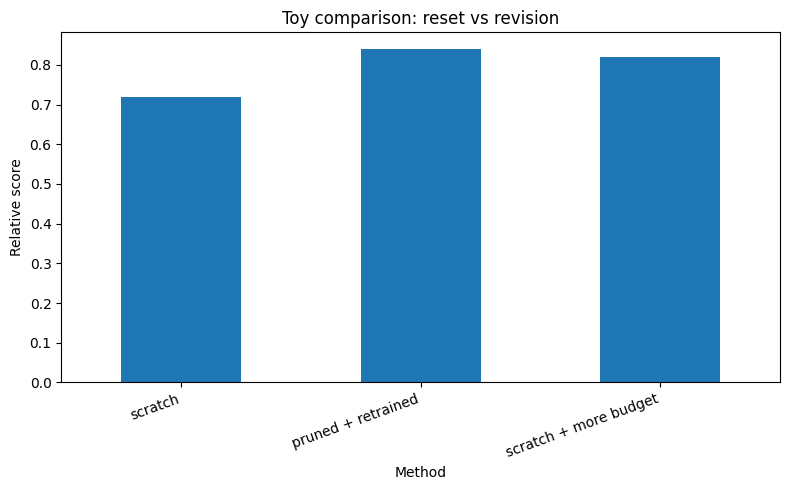

saved: /content/pruning-rml/figures/00_reset_vs_revision.png


In [57]:
fig_path = figures / "00_reset_vs_revision.png"

ax = toy.plot.bar(x="method", y="relative_score", legend=False, figsize=(8, 5))
ax.set_title("Toy comparison: reset vs revision")
ax.set_xlabel("Method")
ax.set_ylabel("Relative score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(fig_path, dpi=160)
plt.show()

print("saved:", fig_path)

In [59]:
!zip -r pruning-rml-outputs.zip figures reports results 2>/dev/null
from google.colab import files
files.download("pruning-rml-outputs.zip")

updating: figures/ (stored 0%)
updating: figures/00_reset_vs_revision.png (deflated 21%)
updating: figures/00_reset_vs_revision_toy.png (deflated 21%)
updating: reports/ (stored 0%)
updating: reports/00_context.md (deflated 41%)
updating: results/ (stored 0%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Done

If the last cell printed:

```text
saved: .../figures/00_reset_vs_revision.png
```

Notebook 00 worked.